# Data Exploration

Question: which companies will default? 

This notebook is the *data story* behind the design. It answers four questions:

1. What does the training population look like (balance, quality, distributions)?
2. Which financial features separate defaulters from survivors?
3. Do the narrative descriptions carry predictive signal — or are they explanation material?
4. What traps does this dataset contain (and how do we avoid them)?

All shared constants come from `src/config.py` — the single source of truth used by the
pipeline, the experiments and the app, so nothing here can drift from the deliverable.

In [9]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import CATEGORICAL, ID, NUMERIC, TARGET, TEXT
from src.data import load_scoring, load_training

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

train = load_training()         
scoring = load_scoring(train)    

print(f"train:   {train.shape[0]} companies x {train.shape[1]} columns")
print(f"scoring: {scoring.shape[0]} companies (no label)")
print(f"default rate: {train[TARGET].mean():.1%} ({train[TARGET].sum()} of {len(train)})")

train:   1000 companies x 14 columns
scoring: 50 companies (no label)
default rate: 17.4% (174 of 1000)


/Users/yasaman/Desktop/fasanara/fasa-credit-assessment/src/data.py:81: UserWarning: possible train->scoring distribution shift (KS p<0.01) in: ['ebitda_margin']
  check_consistency(train, scoring)


## 1. Population overview

- Data quality — `src/data.py` checks no missing values, unique IDs, and clean 1:1 joins before we plot anything. 
- Class balance drives every downstream choice — **17.4% defaults** : This number dictates the metric and the decision policy.
- Why not accuracy? A naive "never defaults" rule scores 82.6% accuracy while catching zero defaulters — a classic imbalance trap.
- What use instead
  - ROC-AUC as the primary ranking metric 
  - A cost-based alert threshold in `src/policy.py` — not the default 0.5 cutoff.

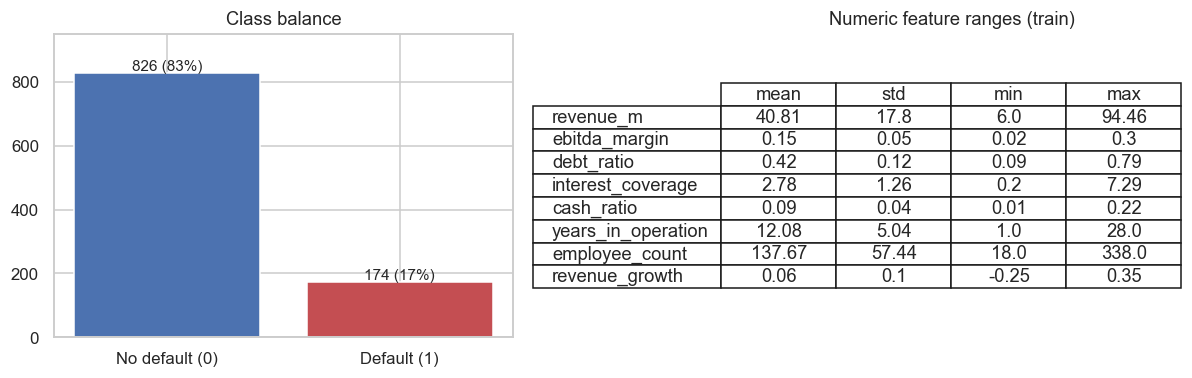

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

counts = train[TARGET].value_counts().sort_index()
bars = axes[0].bar(["No default (0)", "Default (1)"], counts.values, color=["#4c72b0", "#c44e52"])
for b, c in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width() / 2, c + 8, f"{c} ({c/len(train):.0%})",
                 ha="center", fontsize=10)
axes[0].set_title("Class balance")
axes[0].set_ylim(0, counts.max() * 1.15)

train[NUMERIC].describe().T[["mean", "std", "min", "max"]].round(2)
axes[1].axis("off")
tbl = axes[1].table(
    cellText=train[NUMERIC].describe().T[["mean", "std", "min", "max"]].round(2).values,
    rowLabels=NUMERIC, colLabels=["mean", "std", "min", "max"],
    cellLoc="center", loc="center")
tbl.scale(1, 1.25)
axes[1].set_title("Numeric feature ranges (train)")
plt.tight_layout()
plt.show()

## 2. Which financials separate defaulters from survivors?

- Question — which numbers look different for companies that defaulted vs those that did not?
- We look at three things:
  - Charts — each financial ratio for defaulters vs non-defaulters.
  - Correlation — which features go up or down most with default.
  - Sector & country — default rate in each group (e.g. Retail vs Logistics).
- Sanity check — we expect worse debt, liquidity, and margins among defaulters; the plots below confirm whether the data matches that.

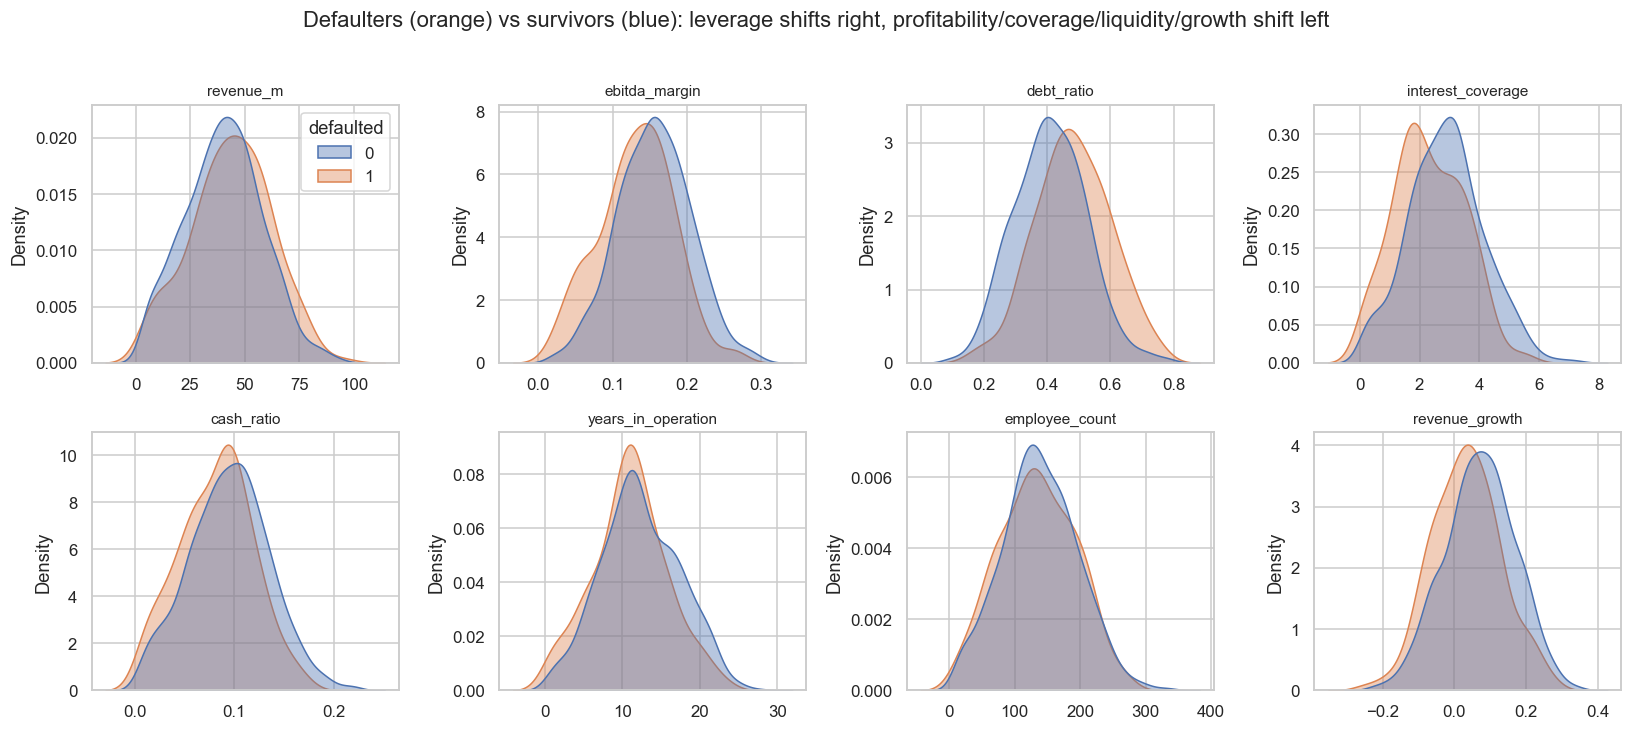

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
for ax, col in zip(axes.ravel(), NUMERIC):
    sns.kdeplot(data=train, x=col, hue=TARGET, fill=True, alpha=0.4,
                common_norm=False, ax=ax, legend=(col == NUMERIC[0]))
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
fig.suptitle("Defaulters (orange) vs survivors (blue): leverage shifts right, "
             "profitability/coverage/liquidity/growth shift left", y=1.02)
plt.tight_layout()
plt.show()

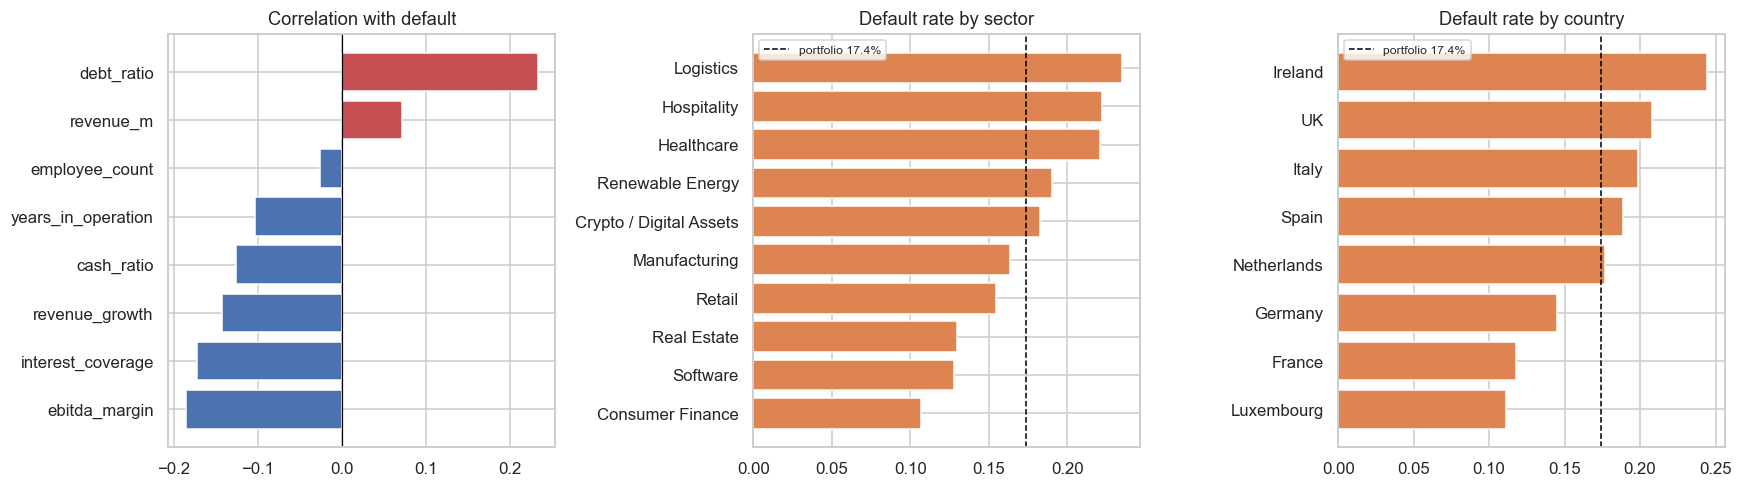

Univariate correlation with default:
debt_ratio            0.233
ebitda_margin        -0.186
interest_coverage    -0.173
revenue_growth       -0.143
cash_ratio           -0.127
years_in_operation   -0.104
revenue_m             0.071
employee_count       -0.026


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

corr = train[NUMERIC + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
colors = ["#c44e52" if v > 0 else "#4c72b0" for v in corr.values]
axes[0].barh(corr.index, corr.values, color=colors)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Correlation with default")

for ax, col in zip(axes[1:], CATEGORICAL):
    rate = train.groupby(col)[TARGET].mean().sort_values()
    ax.barh(rate.index, rate.values, color="#dd8452")
    ax.axvline(train[TARGET].mean(), ls="--", color="black", lw=1,
               label=f"portfolio {train[TARGET].mean():.1%}")
    ax.set_title(f"Default rate by {col}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Univariate correlation with default:")
print(corr.sort_values(key=abs, ascending=False).round(3).to_string())

### Takeaways from section 2

- Most important number: high `debt_ratio` → more defaults (strongest link: +0.23).
- Safer profiles: higher profit (`ebitda_margin`), easier to pay debt (`interest_coverage`), growing sales (`revenue_growth`), more cash (`cash_ratio`).
- Industry effect: default rate ~11% (Consumer Finance) up to ~23% (Logistics).
- Weak signals: company size (`revenue_m`, `employee_count`) does not separate defaulters much.

## 3. Do the narratives predict default?

- Text format: every company uses the same template — sector line, then `"faces …"` risks, sometimes `"benefits from …"` strengths, then a fixed closing sentence.
- Simple test: if text matters, more risk phrases should mean more defaults.
- We only count default % per phrase. Full tests (phrases-only model, embeddings) are in `02_experiments.ipynb`.
- First look: almost every phrase sits near the 17.4% average — so text is better for memos than for the model.

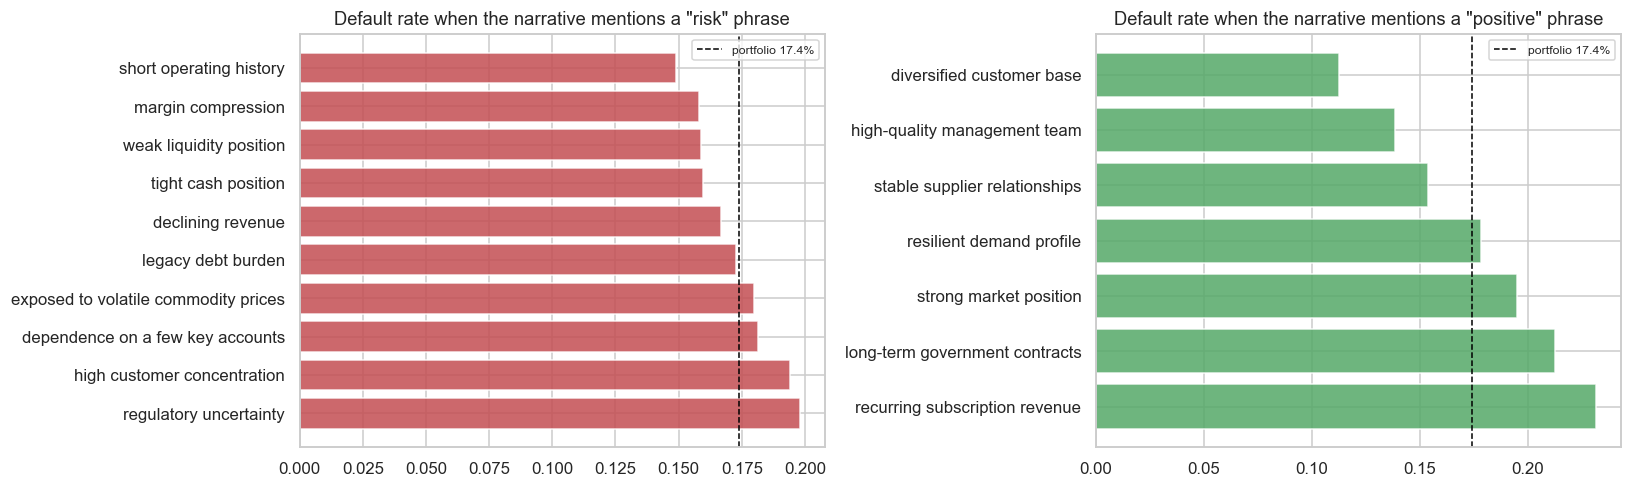

Default rate by number of risk phrases in the narrative:
         mean  count
n_risk              
1       0.160    331
2       0.213    328
3       0.150    341

Default rate by number of positive phrases:
        mean  count
n_pos              
0      0.170    487
1      0.177    513


In [6]:
from src.explain import narrative_signals

signals = train[TEXT].apply(narrative_signals)
train_sig = train.assign(
    n_risk=signals.apply(lambda s: len(s[0])),
    n_pos=signals.apply(lambda s: len(s[1])),
)

# Default rate per individual phrase
phrase_rates = {}
for kind_idx, kind in [(0, "risk"), (1, "positive")]:
    universe = sorted({p for s in signals for p in s[kind_idx]})
    for p in universe:
        mask = signals.apply(lambda s: p in s[kind_idx])
        phrase_rates[(kind, p)] = (train.loc[mask, TARGET].mean(), int(mask.sum()))

rate_df = (pd.DataFrame([(k[0], k[1], v[0], v[1]) for k, v in phrase_rates.items()],
                        columns=["kind", "phrase", "default_rate", "n"])
           .sort_values(["kind", "default_rate"], ascending=[True, False]))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
for ax, kind, color in [(axes[0], "risk", "#c44e52"), (axes[1], "positive", "#55a868")]:
    sub = rate_df[rate_df["kind"] == kind]
    ax.barh(sub["phrase"], sub["default_rate"], color=color, alpha=0.85)
    ax.axvline(train[TARGET].mean(), ls="--", color="black", lw=1,
               label=f"portfolio {train[TARGET].mean():.1%}")
    ax.set_title(f'Default rate when the narrative mentions a "{kind}" phrase')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Default rate by number of risk phrases in the narrative:")
print(train_sig.groupby("n_risk")[TARGET].agg(["mean", "count"]).round(3).to_string())
print("\nDefault rate by number of positive phrases:")
print(train_sig.groupby("n_pos")[TARGET].agg(["mean", "count"]).round(3).to_string())

### Takeaways from section 3

- Text does not predict well — no phrase moves default rate far from 17.4%.
- Important: some “positive” phrases still have *high* default rates.
- More risk phrases ≠ more defaults** — the pattern is messy, not a clean rule.
- My choice: no text in the model; use it only in analyst memos (`src/explain.py`).

## 4. Dataset traps

Two fields we **do not** use:

In [7]:
# Trap 1: company_name is recycled between train and scoring with different attributes
overlap = set(train["company_name"]) & set(scoring["company_name"])
example = sorted(overlap)[0]
comparison = pd.concat([
    train.loc[train["company_name"] == example, [ID, "company_name", "sector", "revenue_m"]],
    scoring.loc[scoring["company_name"] == example, [ID, "company_name", "sector", "revenue_m"]],
])
print(f"{len(overlap)} of {len(scoring)} scoring company names also appear in train, "
      f"but with different identities, e.g.:")
display(comparison)

# Trap 2: the narrative's sector mention is 100% redundant with the sector column
import re
def narrative_sector(text: str) -> str:
    return re.search(r"operates in the ([^.]+?) (?:sector|market)", text).group(1).lower()

redundant = (train[TEXT].apply(narrative_sector)
             == train["sector"].str.lower()).mean()
print(f"\nnarrative sector mention matches the sector column in {redundant:.0%} of rows")

50 of 50 scoring company names also appear in train, but with different identities, e.g.:


,company_id,company_name,sector,revenue_m
0,1,Aster Holdings #0001,Retail,28.640542
0,1001,Aster Holdings #0001,Manufacturing,67.516071



narrative sector mention matches the sector column in 100% of rows


- **`company_name`** — dropped (cosmetic only; same name can mean different companies in train vs scoring).
- **Sector sentence in text** — ignored; we already have the `sector` column.

## 5. What EDA tells us to build

| What we saw | What we decided |
|---|---|
| 17.4% defaults — accuracy misleading | Use ROC-AUC + cost-based threshold (`src/policy.py`) |
| Financials carry signal, signs make sense | Logistic regression on 8 ratios + sector/country (`src/model.py`) |
| Narratives do not predict default | Text only in memos (`src/explain.py`), not in the model |
| `company_name` reused across files | Never use it as a feature |

**Next:** `02_experiments.ipynb` — measure each choice with ablations.